In [114]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [115]:
df = pd.read_csv("../../data/smartcart_customers.csv")
df.shape

(2240, 22)

In [116]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [117]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing

### 1. Handle Missing Values

In [118]:
df["Income"] = df ["Income"].fillna(df["Income"].median)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [119]:
#df.isnull().sum()

## 2. Feature Engineering

In [120]:
# Age 
df["Age"] =  2026-df["Year_Birth"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [121]:
# Customer joining date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = reference_date-df["Dt_Customer"]
# Show only columns causing the error
print(df.select_dtypes(include=['timedelta', 'datetime']).dtypes)
# 1. Convert the timedelta column into an integer of days
df['Customer_Tenure_Days'] = df['Customer_Tenure_Days'].dt.days

In [122]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663 days
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113 days
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312 days
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139 days
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161 days


In [123]:
# Spending
df["Total_Spending"] = df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]


In [124]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days',
       'Total_Spending'],
      dtype='object')

In [125]:
df["Total_Children"] = df["Kidhome"]+df["Teenhome"]

In [126]:
# Education 
df["Education"].value_counts()

df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate",
    "PhD":"Postgraduate"
})
df["Education"].value_counts()


Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [127]:
# Marital Status
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663 days,1617,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113 days,27,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312 days,776,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139 days,53,1
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161 days,422,1


In [128]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [129]:
df["Living_With"]=df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Alone":"Alone",
    "Widow":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone"
})
df["Marital_Status"].value_counts()


Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

## Drop Columns

In [130]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [131]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
cols_to_drop= cols + spending_cols
df_cleaned = df.drop(columns = cols_to_drop)

In [132]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_Children',
       'Living_With'],
      dtype='object')

In [133]:
df_cleaned.shape

(2240, 15)

In [134]:
df.shape

(2240, 27)

In [135]:
df_cleaned.head()
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663 days,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113 days,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312 days,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139 days,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161 days,422,1,Partner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduate,Married,61223.0,0,1,2013-06-13,46,709,...,3,4,5,0,0,59,381 days,1341,1,Partner
2236,4001,1946,Postgraduate,Together,64014.0,2,1,2014-06-10,56,406,...,2,5,7,0,0,80,19 days,444,3,Partner
2237,7270,1981,Graduate,Divorced,56981.0,0,0,2014-01-25,91,908,...,3,13,6,0,0,45,155 days,1241,0,Alone
2238,8235,1956,Postgraduate,Together,69245.0,0,1,2014-01-24,8,428,...,5,10,3,0,0,70,156 days,843,1,Partner


## Outliers

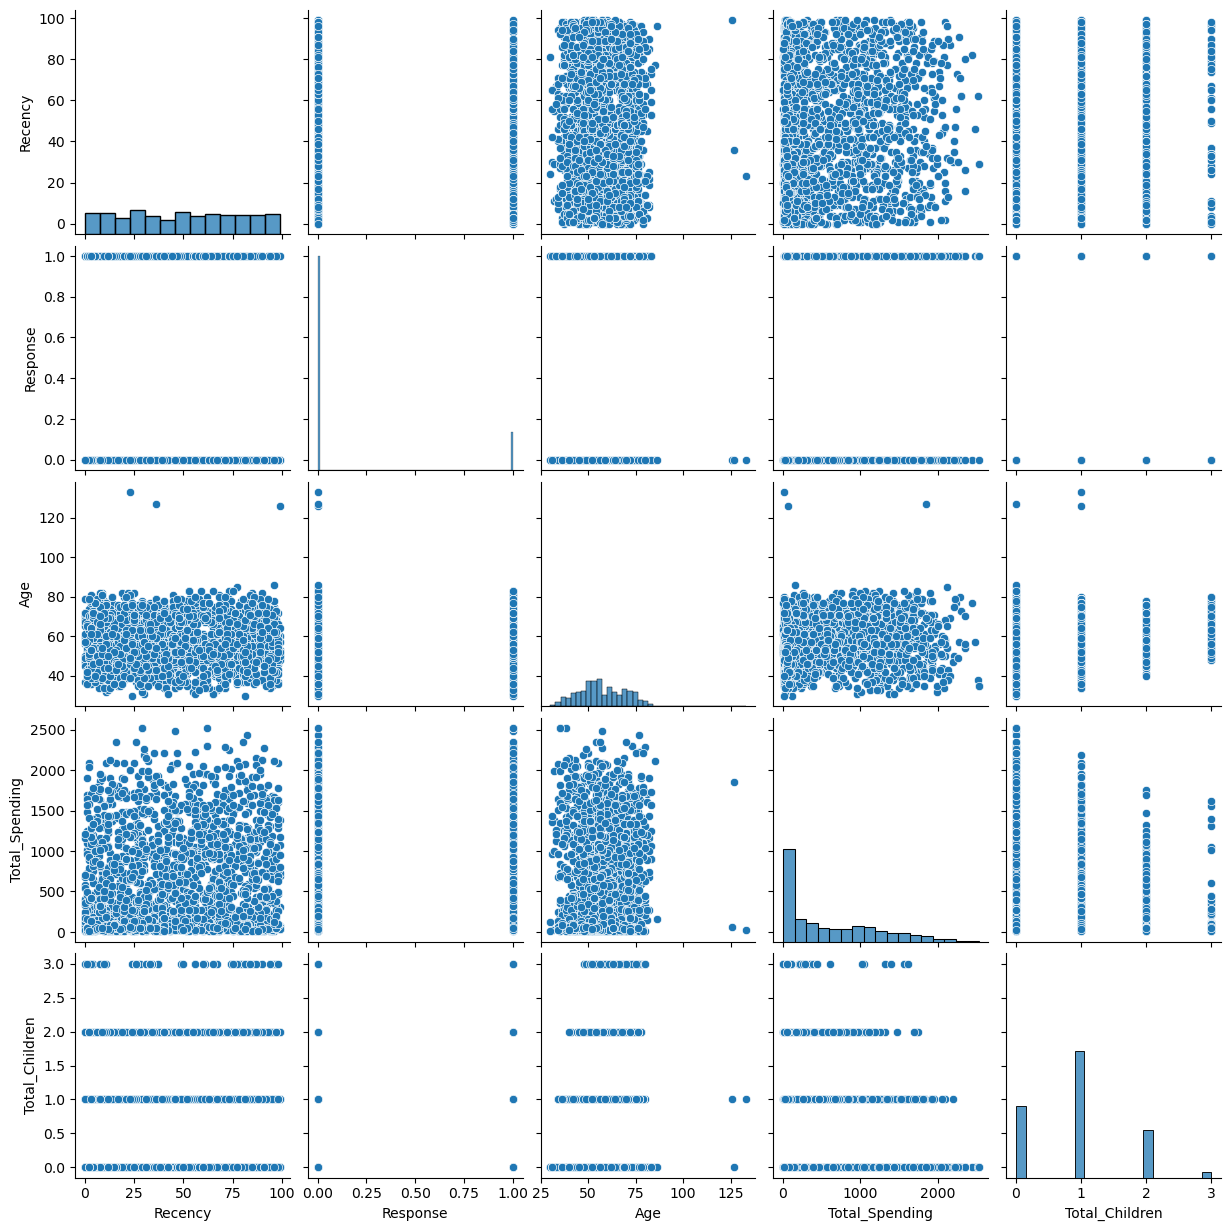

In [136]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]
# Realtive Plots of some-features - pair plot
sns.pairplot(df_cleaned[cols])

In [137]:
print("Data type of Income:", df_cleaned['Income'].dtype)
print("Number of missing values in Income:", df_cleaned['Income'].isna().sum())


Data type of Income: object
Number of missing values in Income: 0


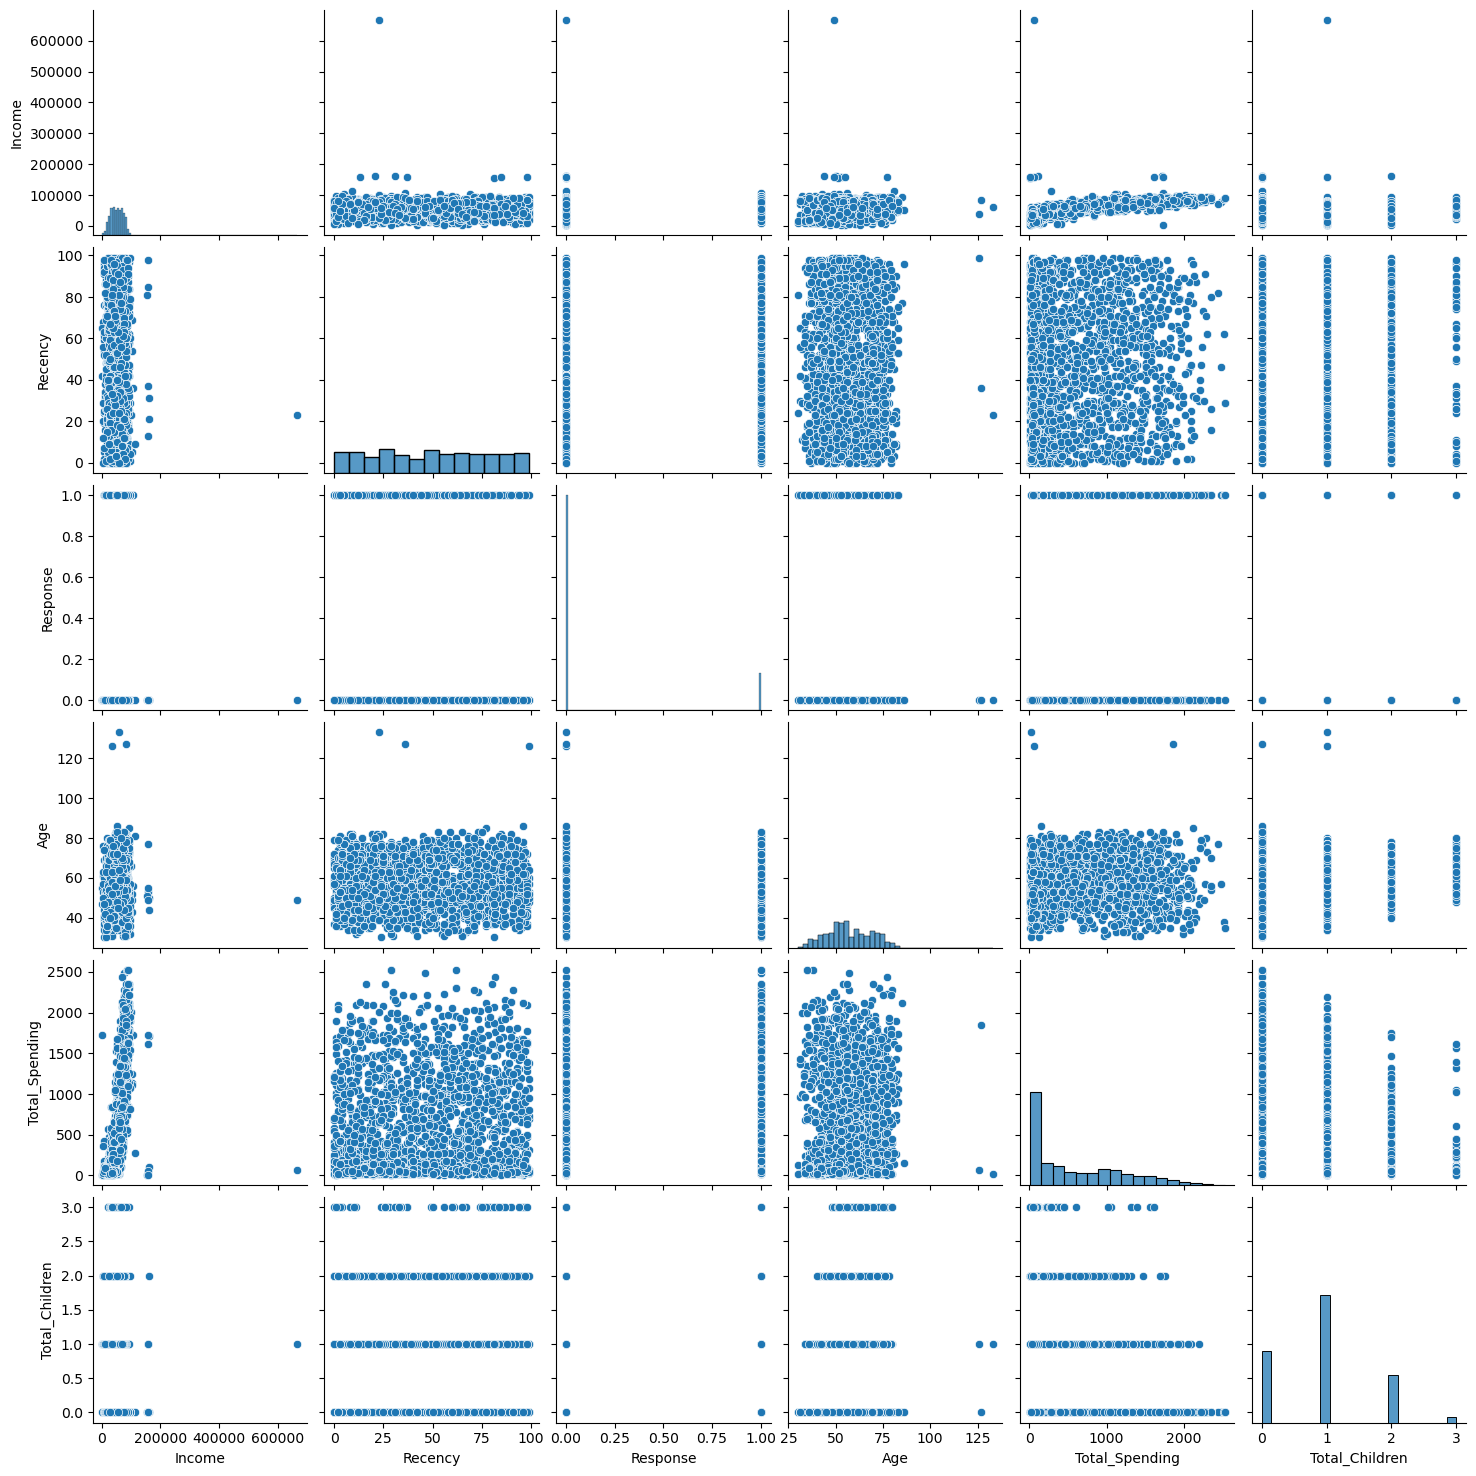

In [138]:
# 1. Force convert to numeric (any stubborn text strings will turn into NaN)
df_cleaned['Income'] = pd.to_numeric(df_cleaned['Income'], errors='coerce')

# 2. Fill any newly created NaN values with the median just in case
df_cleaned['Income'] = df_cleaned['Income'].fillna(df_cleaned['Income'].median())

# 3. pairplot
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]
sns.pairplot(df_cleaned[cols])


In [139]:
# Remove Outliers
print("data size with outliers",len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["Income"]<600_000)]
df_cleaned = df_cleaned[(df_cleaned["Age"]<90)]

print("data size without outliers",len(df_cleaned))


data size with outliers 2240
data size without outliers 2236


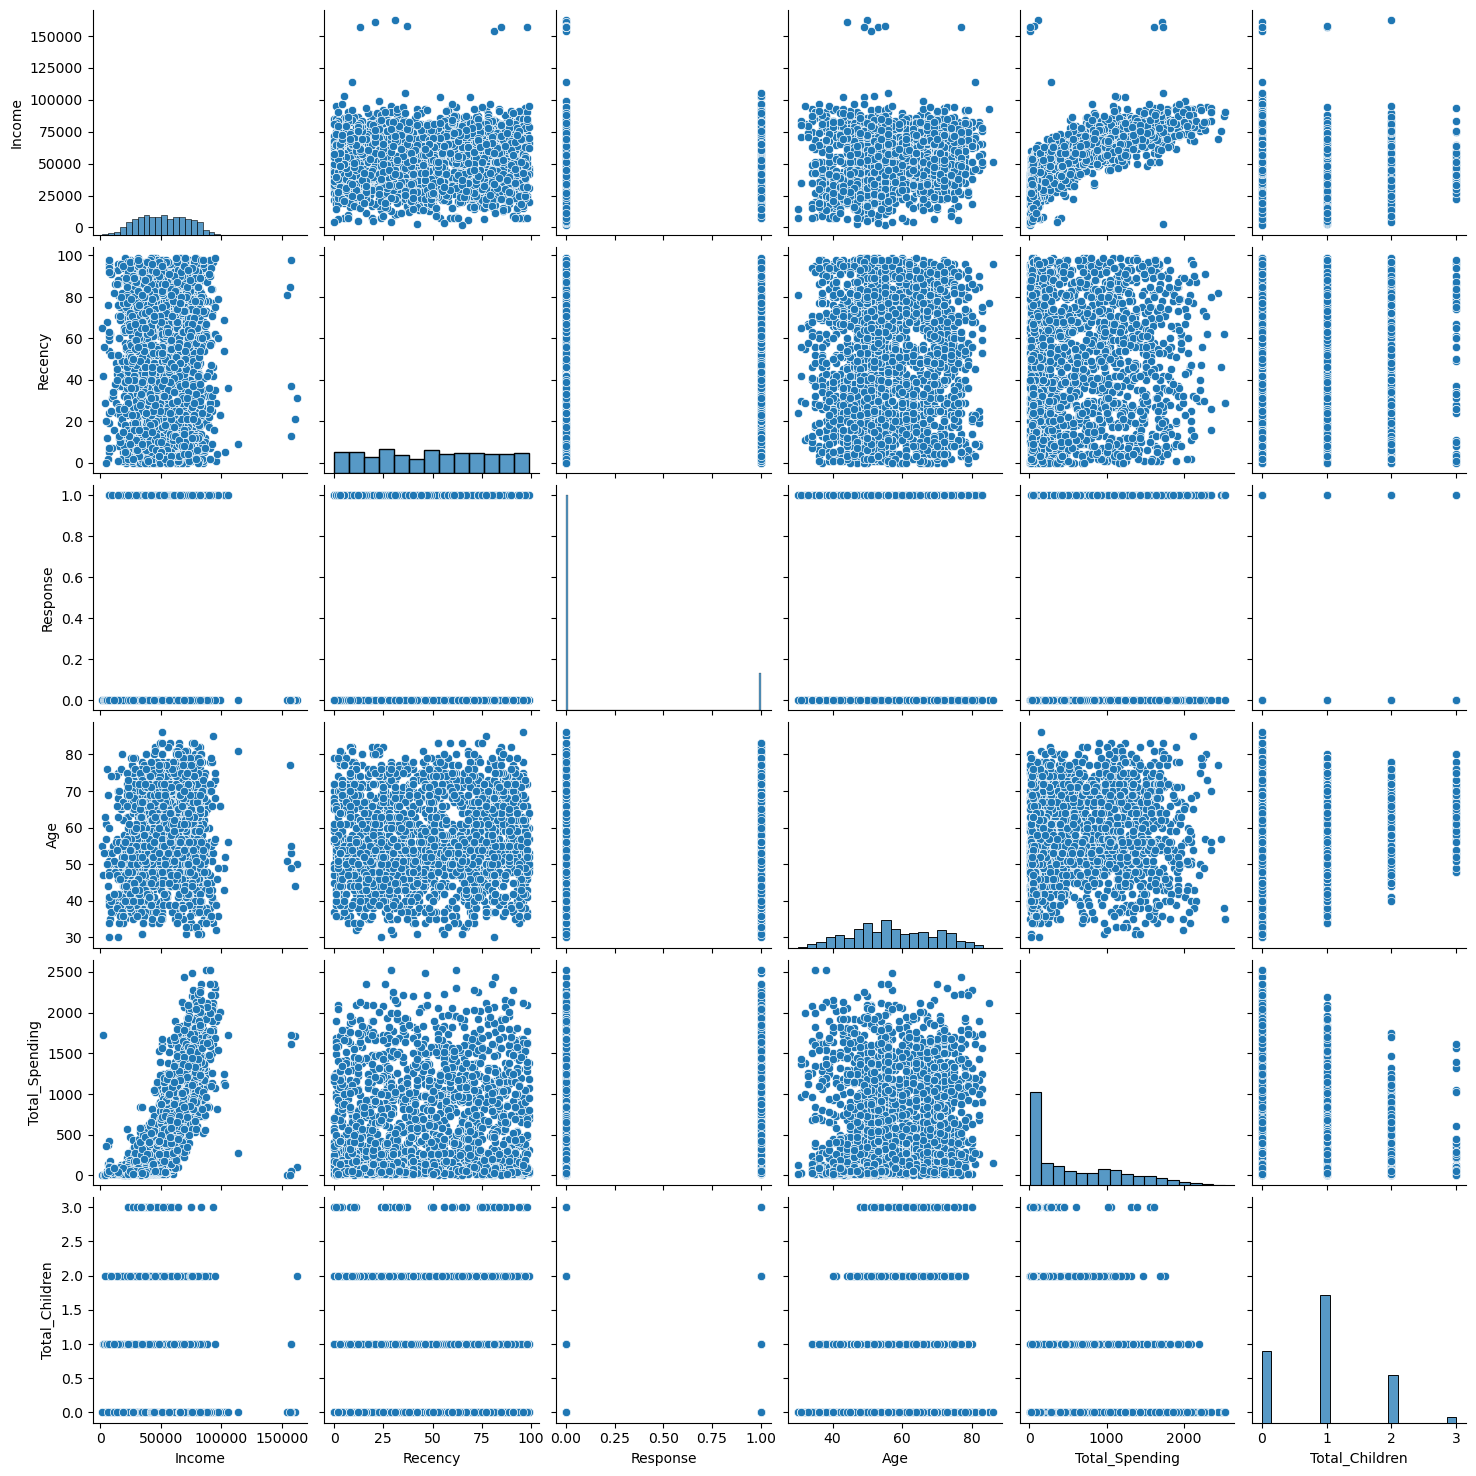

In [140]:
# 3. pairplot
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]
sns.pairplot(df_cleaned[cols])

## HeatMap 

In [141]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

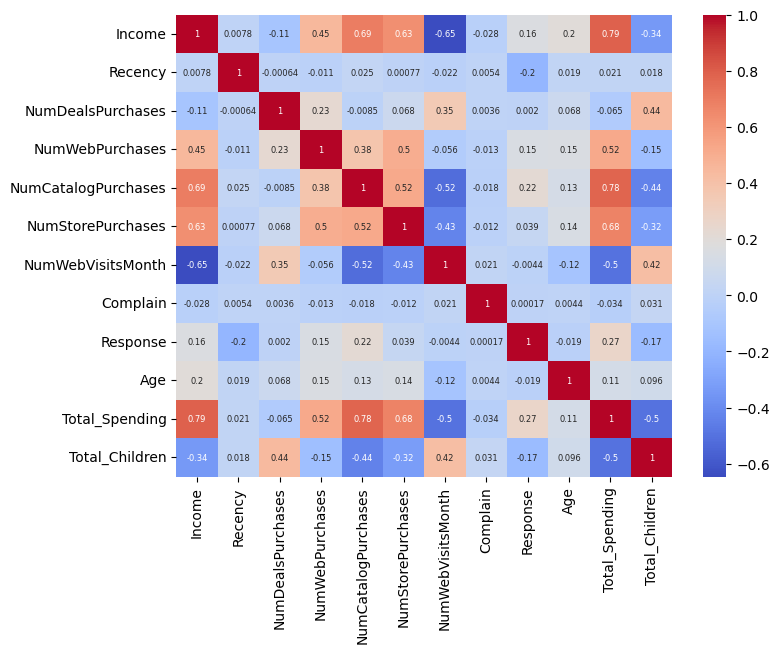

In [142]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot = True,
    annot_kws={"size":6},
    cmap = "coolwarm"
)

In [143]:
df_cleaned.shape

(2236, 15)

In [144]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663 days,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113 days,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312 days,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139 days,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161 days,422,1,Partner


## Encoding

In [145]:
from sklearn.preprocessing import OneHotEncoder

In [146]:
ohe = OneHotEncoder()
cat_cols = ["Education","Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [147]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [148]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [149]:
enc_df.shape

(2236, 5)

In [150]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [151]:
df_encoded.shape

(2236, 18)

In [152]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663 days,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113 days,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312 days,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139 days,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161 days,422,1,0.0,1.0,0.0,0.0,1.0


## Scaling

In [153]:
from sklearn.preprocessing import StandardScaler

In [154]:
# Show only columns causing the error
print(df_encoded.select_dtypes(include=['timedelta', 'datetime']).dtypes)
# 1. Convert the timedelta column into an integer of days
df_encoded['Customer_Tenure_Days'] = df_encoded['Customer_Tenure_Days'].dt.days

Customer_Tenure_Days    timedelta64[ns]
dtype: object


In [155]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)

## Visualize

In [156]:
df_scaled.shape

(2236, 18)

In [157]:
# 2D
from sklearn.decomposition import PCA

In [171]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

In [172]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

<Axes: >

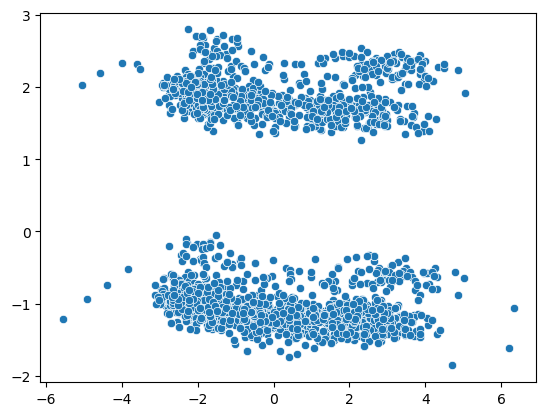

In [170]:
# Plot 
sns.scatterplot(x=df_pca[:,0],y=df_pca[:,1])

In [173]:
pca = PCA(n_components=3)
df_pca = pca.fit_transform(df_scaled)

In [174]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d Projection')

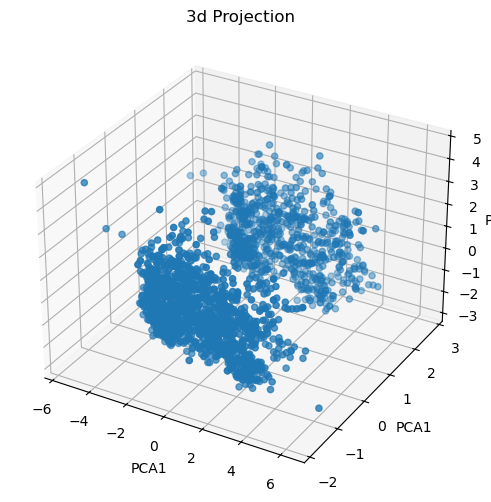

In [175]:
# Plot 
fig= plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")

ax.scatter(df_pca[:,0],df_pca[:,1],df_pca[:,2 ])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA1")
ax.set_zlabel("PCA1")
ax.set_title("3d Projection")

## Anakyze K Value

### 1. Elbow Method

In [178]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(df_pca)
    wcss.append(kmeans.inertia_)

In [185]:
knee=KneeLocator(range(2,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [186]:
print("best k=",optimal_k)

best k= 5


Text(0, 0.5, 'wcss')

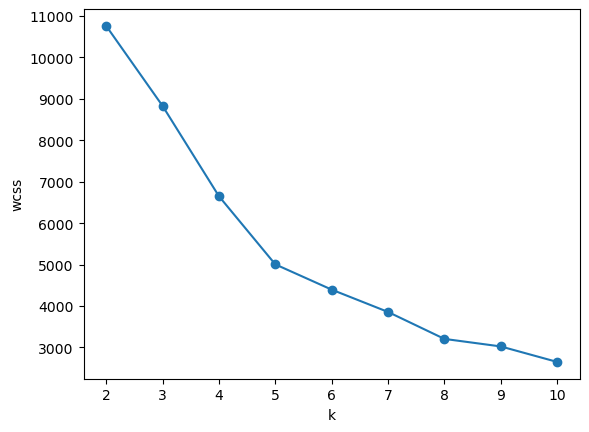

In [188]:
# plot 
plt.plot(range(2,11),wcss,marker='o')
plt.xlabel("k")
plt.ylabel("wcss")

### 2. Silhouette Score

In [190]:
from sklearn.metrics import silhouette_score

scores= []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(df_pca)
    score = silhouette_score(df_pca,labels)
    scores.append(score)

Text(0, 0.5, 'silhouette_score')

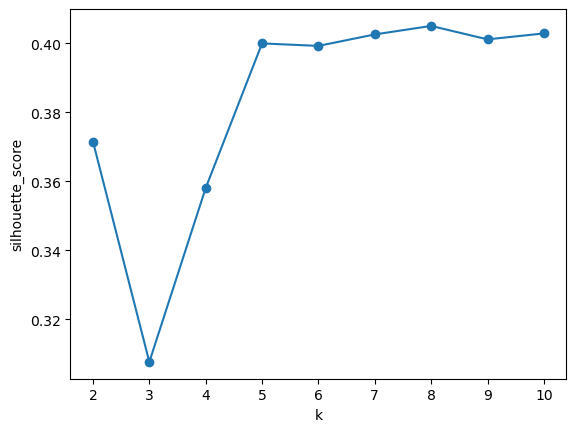

In [192]:
# plot 
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("k")
plt.ylabel("silhouette_score")

Text(0, 0.5, 'ss')

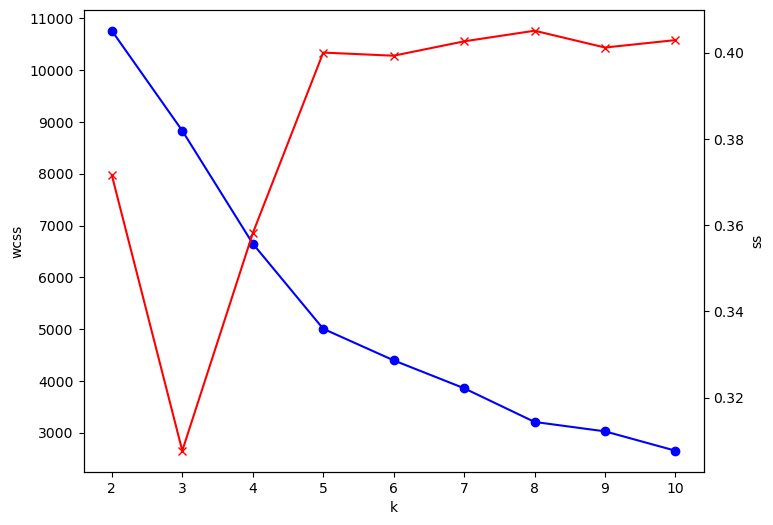

In [202]:
#### Combine plot 
k_range = range(2,11)

fig,ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red")
ax2.set_ylabel("ss")

## Clustering

In [208]:
# KMeans

kmeans = KMeans(n_clusters=5,random_state=42)
labels_kmeans = kmeans.fit_predict(df_pca)

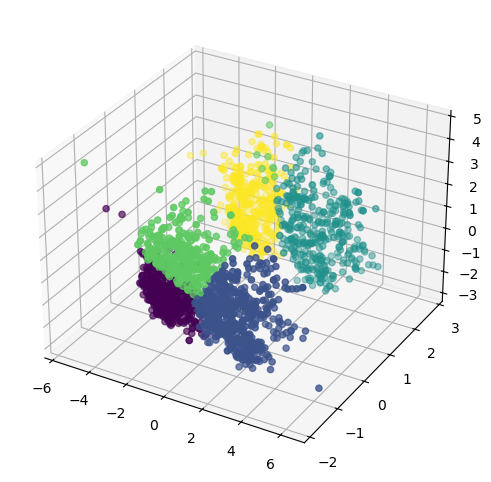

In [209]:
fig= plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")

ax.scatter(df_pca[:,0],df_pca[:,1],df_pca[:,2 ],c=labels_kmeans)

In [211]:
## Agglomerative clustering

from sklearn.cluster import AgglomerativeClustering


In [215]:
agg_clf = AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg = agg_clf.fit_predict(df_pca)

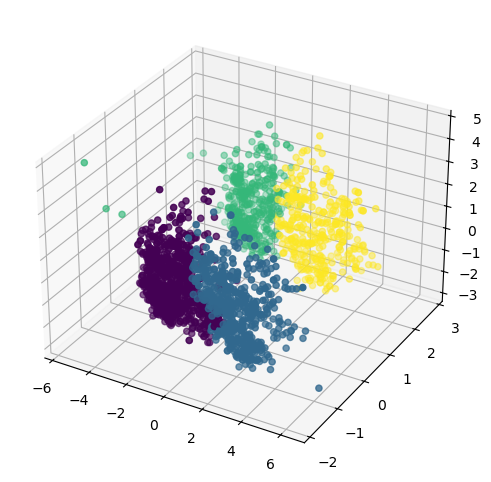

In [216]:
fig= plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")

ax.scatter(df_pca[:,0],df_pca[:,1],df_pca[:,2 ],c=labels_agg)

## Characterization of Clusters 

In [217]:
df_cleaned["labels"] = labels_agg

In [218]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With,labels
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663 days,1617,0,Alone,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113 days,27,2,Alone,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312 days,776,0,Partner,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139 days,53,1,Partner,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161 days,422,1,Partner,0


![alt text](image.png)